# Spatial Transformations for the myCobot 280 Labs
## Student Notebook Template

Run this notebook from the myCobot lab virtual environment `~/venvs/mycobot`. Activate it first with `source ~/venvs/mycobot/bin/activate`, then launch Jupyter from that environment. Use the same environment for the ROS 2 commands in this lab series.

In this notebook, you can use the [Spatialmath package]( https://bdaiinstitute.github.io/spatialmath-python/ )

and/or the [SciPy package](https://docs.scipy.org/doc/scipy/index.html).
## Transformations and Rotations

In [48]:
# %matplotlib widget works best when ipympl is already available in the active lab environment
%matplotlib widget 
import numpy as np
import matplotlib.pyplot as plt
import os
# alternative 1: SciPy
import scipy
from scipy.spatial.transform import Rotation as R 
from scipy.spatial.transform import Slerp
# alternative 2: spatialmath (includes homogeneous transforms)
from spatialmath import SO3, SE3 
from spatialmath.base import rotx, rotz, transl, trotx, tr2eul, tr2rpy, tr2angvec, rpy2tr

np.set_printoptions(precision=4)

### 1. Translation along x- and z-axis
Define a 3-by-1 column vector _trvecx_ for the translation $\boldsymbol{t}_x$ along the x-axis by $a=1$.

In [49]:
a = 1
trvecx = np.array([[a],[0],[0]])
print(trvecx)

[[1]
 [0]
 [0]]


Define a 3-by-1 column vector _trvecz_ for the translation $\boldsymbol{t}_z$ along the z-axis by $d=2$.

In [50]:
d = 2
trvecz = np.array([[0],[0],[d]])
print(trvecz)

[[0]
 [0]
 [2]]


### 2. Rotation along x- and z-axis
Define a rotation matrix _rotmx_ for the rotation $\boldsymbol{R}_x$ around the x-axis by $\alpha = \pi/2$.

<!-- SciPy: create a rotation object with `R.from_rotvec(...)` and extract the rotation matrix with `r.as_matrix()`. -->

Spatialmath: use `rotx(...)` or `SO3.Rx(...)`. The first one will return the rotation matrix as a numpy array, the second one will return an SO3 object.

In [51]:
alpha=np.pi/2
rotmx = np.array([[1, 0, 0],
                  [0, np.cos(alpha), -np.sin(alpha)],
                  [0, np.sin(alpha), np.cos(alpha)]])
print(rotmx)

## alternative: spatialmath
rotmx = rotx(alpha)
print(rotmx)


[[ 1.0000e+00  0.0000e+00  0.0000e+00]
 [ 0.0000e+00  6.1232e-17 -1.0000e+00]
 [ 0.0000e+00  1.0000e+00  6.1232e-17]]
[[ 1.0000e+00  0.0000e+00  0.0000e+00]
 [ 0.0000e+00  6.1232e-17 -1.0000e+00]
 [ 0.0000e+00  1.0000e+00  6.1232e-17]]


Define a rotation matrix _rotmz_ for the rotation $\boldsymbol{R}_z$ around the z-axis by $\theta = \pi/4$.

<!-- SciPy: create a rotation object with `R.from_rotvec(...)` and extract the rotation matrix with `r.as_matrix()`. -->

Spatialmath: use `rotz(...)` or `SO3.Rz(...)`. The first one will return the rotation matrix as a numpy array, the second one will return an SO3 object.

In [52]:
theta=np.pi/4
rotmz = np.array([[np.cos(theta), -np.sin(theta), 0],
                  [np.sin(theta), np.cos(theta), 0],
                  [0, 0, 1]])
print(rotmz)

# alternative: spatialmath -> For later tasks, this option is more convenient
rotmz = rotz(theta)
print(rotmz)

[[ 0.7071 -0.7071  0.    ]
 [ 0.7071  0.7071  0.    ]
 [ 0.      0.      1.    ]]
[[ 0.7071 -0.7071  0.    ]
 [ 0.7071  0.7071  0.    ]
 [ 0.      0.      1.    ]]


### 3. Composition of rotations
Compute the rotation _rotmc_ resulting from sequential rotations first along the x-axis and then about the <ins>current</ins> z-axis (current frame, intrinsic)

In [53]:
rotmc = rotmx @ rotmz # intrinsic with respect to current frame --> Note the @ sign for the correct matrix/vector multiplications
print(rotmc)

[[ 7.0711e-01 -7.0711e-01  0.0000e+00]
 [ 4.3298e-17  4.3298e-17 -1.0000e+00]
 [ 7.0711e-01  7.0711e-01  6.1232e-17]]


Compute the rotation _rotmf_ resulting from sequential rotations along the x-axis and then along the <ins>fixed</ins> z-axis (fixed frame, extrinsic).

In [54]:
rotmf = rotmz @ rotmx  # extrinsic with respect to fixed frame
print(rotmf)

[[ 7.0711e-01 -4.3298e-17  7.0711e-01]
 [ 7.0711e-01  4.3298e-17 -7.0711e-01]
 [ 0.0000e+00  1.0000e+00  6.1232e-17]]


### 4. Apply rotations to 3D vector
Apply the combined rotations _rotmc_, _rotmf_  to the 1-by-3 column vector $p$ ($\boldsymbol{p} = \begin{bmatrix}1 & 2 & 0\end{bmatrix}^{T}$ ). 

In [55]:
p = np.array([[1], [2], [0]])
pc = rotmc @ p
pf = rotmf @ p
print("pc: ")
print(pc)
print("pf: ")
print(pf)

pc: 
[[-7.0711e-01]
 [ 1.2989e-16]
 [ 2.1213e+00]]
pf: 
[[0.7071]
 [0.7071]
 [2.    ]]


### 5. Apply rotations and translations to 3D vector
Apply the transformation
\begin{equation}
\boldsymbol{p}' = \boldsymbol{R}_x (\boldsymbol{R}_z(\boldsymbol{p} + \boldsymbol{t}_z)+\boldsymbol{t}_x)
\end{equation}
that corresponds to the consecutive application of the translation along z-axis by $d=2$, rotation along z-axis by $\theta = \pi/4$, translation along the x-axis by $a=1$ and final rotation along the x-axis by $\alpha = \pi/2$ to the 1-by-3 column vector $p$.

In [56]:
ptf = rotmx @ (rotmz @ (p + trvecz) + trvecx)
print(ptf)

[[ 0.2929]
 [-2.    ]
 [ 2.1213]]


## Homogeneous transforms
### 6. Convert translations to homogeneous transforms
Define a transform _tformtx_ for the homogeneous transformation $\boldsymbol{H}_{tx}$ that correspond to the previously defined translation _trvecx_ along the x-axis by $a=1$.

Spatialmath: use `transl(...)` to create a homogeneous transform array.

In [57]:
tformtx = np.eye(4)
tformtx[:3, 3] = trvecx.flatten()

print(tformtx)

# alternative: spatialmath
# tformtx = SE3(trvecx)
tformtx =transl(trvecx.flatten()) 
print(tformtx)

# SciPy doesn't have homogeneous transforms

[[1. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
[[1. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


Define a transform _tformtz_ for the homogeneous transformation $\boldsymbol{H}_{tz}$ that correspond to the previously defined translation _trvecz_ along the z-axis by $d=2$.

In [58]:
tformtz = np.eye(4)
tformtz[:3, 3] = trvecz.flatten()
print(tformtz)

# alternative: spatialmath
# tformtz = SE3(trvecz)
tformtz =transl(trvecz.flatten()) 
print(tformtz)

[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 2.]
 [0. 0. 0. 1.]]
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 2.]
 [0. 0. 0. 1.]]


### 7. Convert rotations to homogeneous transforms
Define a transform _tformrotx_ for the homogeneous transformation $\boldsymbol{H}_{Rx}$ that corresponds to the previously defined rotation _rotmx_ around the x-axis by $\alpha = \pi/2$.

Spatialmath: use `trotx(...)` to create an array for the homogeneous transform matrix. 

In [59]:
tformrotx = np.eye(4)
tformrotx[:3,:3] = rotmx
print(tformrotx)

# alternative
tformrotx = trotx(alpha)
print(tformrotx)

[[ 1.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00]
 [ 0.0000e+00  6.1232e-17 -1.0000e+00  0.0000e+00]
 [ 0.0000e+00  1.0000e+00  6.1232e-17  0.0000e+00]
 [ 0.0000e+00  0.0000e+00  0.0000e+00  1.0000e+00]]
[[ 1.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00]
 [ 0.0000e+00  6.1232e-17 -1.0000e+00  0.0000e+00]
 [ 0.0000e+00  1.0000e+00  6.1232e-17  0.0000e+00]
 [ 0.0000e+00  0.0000e+00  0.0000e+00  1.0000e+00]]


Define a homogeneous transform _tformrotz_ for the homogeneous transformation $\boldsymbol{H}_{Rz}$ that corresponds to the previously defined rotation _rotmz_ around the z-axis by $\theta = \pi/4$.

Spatialmath: use `SE3.Rz(...)` to create a homogeneous transform and convert it to an array if needed. 

In [60]:
tformrotz = np.eye(4)
tformrotz[:3,:3] = rotmz
print(tformrotz)

# alternative: spatialmath
tformrotz = np.array(SE3.Rz(theta))
print(tformrotz)

[[ 0.7071 -0.7071  0.      0.    ]
 [ 0.7071  0.7071  0.      0.    ]
 [ 0.      0.      1.      0.    ]
 [ 0.      0.      0.      1.    ]]
[[ 0.7071 -0.7071  0.      0.    ]
 [ 0.7071  0.7071  0.      0.    ]
 [ 0.      0.      1.      0.    ]
 [ 0.      0.      0.      1.    ]]


### 8. Composition of homogeneous transforms w.r.t. current frame
Generate a homogeneous transformation _tformdhc_ that corresponds to the consecutive application of the translation along z-axis by $d = 2$, rotation along z-axis by $\theta = \pi/4$, translation along the new x-axis by $a = 1$ and final rotation along the new x-axis by $\alpha=\pi/2$. Generate _tformdhc_ by post-multiplying the transforms _tformtz_, _tformrotz_, _tformtx_ and _tformrotx_.
\begin{equation}
\boldsymbol{H}_{dhc} = \boldsymbol{H}_{tz} \boldsymbol{H}_{Rz}\boldsymbol{H}_{tx}\boldsymbol{H}_{Rx}
\end{equation}
which corresponds to transformations w.r.t. current frame.

In [61]:
tformdhc =tformtz @ tformrotz @ tformtx @ tformrotx
print(tformdhc)

[[ 7.0711e-01 -4.3298e-17  7.0711e-01  7.0711e-01]
 [ 7.0711e-01  4.3298e-17 -7.0711e-01  7.0711e-01]
 [ 0.0000e+00  1.0000e+00  6.1232e-17  2.0000e+00]
 [ 0.0000e+00  0.0000e+00  0.0000e+00  1.0000e+00]]


This same composition of elemental translations and rotations provides the basis for the Denavit-Hartenberg forward-kinematics work used later in the myCobot 280 lab series. The next section uses the same ideas to build kinematic intuition before you work with the full myCobot 280 manipulator.

Note: The myCobot 280 URDF encodes each joint as an origin xyz/rpy transform followed by an axis-angle rotation, rather than using the four classical DH parameters ($d$, $\theta$, $a$, $\alpha$) directly. Lab 2 (Forward Kinematics) covers this distinction in detail. The underlying composition principle — chaining homogeneous transforms from base to end-effector — is the same.

### 9. Composition of homogeneous transforms w.r.t. fixed frame
Generate a homogeneous transformation _tformdhf_ that corresponds to the consecutive application of the translation along the fixed z-axis by $d = 2$, rotation about the fixed z-axis by $\theta = \pi/4$, translation along the fixed x-axis by $a = 1$ and final rotation about the fixed x-axis by $\alpha = \pi/2$. Generate _tformdhf_ by post-multiplying the transforms _tformtz_, _tformrotz_, _tformtx_ and _tformrotx_.
\begin{equation}
\boldsymbol{H}_{dhf} = \boldsymbol{H}_{Rx} \boldsymbol{H}_{tx}\boldsymbol{H}_{Rz}\boldsymbol{H}_{tz}
\end{equation}
which corresponds to transformations w.r.t. fixed frames.

In [62]:
tformdhf = tformrotx @ tformtx @ tformrotz @ tformtz
print(tformdhf)

[[ 7.0711e-01 -7.0711e-01  0.0000e+00  1.0000e+00]
 [ 4.3298e-17  4.3298e-17 -1.0000e+00 -2.0000e+00]
 [ 7.0711e-01  7.0711e-01  6.1232e-17  1.2246e-16]
 [ 0.0000e+00  0.0000e+00  0.0000e+00  1.0000e+00]]


### 10. Apply homogeneous transform to homogeneous 4D vector
Apply the homogeneous transform tformdhf to the homogeneous 1-by-4 column vector $P$ ($\boldsymbol{P}=\begin{bmatrix} 1 & 2 & 0 & 1\end{bmatrix}^T$)
\begin{equation}
\boldsymbol{P}' = \boldsymbol{H}_{dhf}\boldsymbol{P}
\end{equation}

In [63]:
P = np.append(p,1)
Ptf = tformdhf @ P
print(Ptf)

[ 0.2929 -2.      2.1213  1.    ]


### 11. Compare 3D vector and 4D vector for equality
Compare the corresponding resulting homogeneous 4D vector $\boldsymbol{P}'$ with the 3D vector $\boldsymbol{p}'$ previously generated by the application of the same sequence of transformations in task 5. The 3D projection of $\boldsymbol{P}'$ should equal $\boldsymbol{p}'$.

In [64]:
if (np.isclose(ptf.flatten(), Ptf[:3] / Ptf[3])).all():
    print("ptf and Ptf are equal")
else:
    print("ptf and Ptf are not equal")

ptf and Ptf are equal


## Simplified Frame Chain for the myCobot 280 Labs

These next tasks prepare you for later work with the myCobot 280 manipulator. Use the [Roboticstoolbox](https://pypi.org/project/roboticstoolbox-python/) package to build a simple fixed-transform chain in the myCobot 280 lab context. This is a fixed-transform teaching chain, not the full myCobot 280 kinematic model used in later labs.

In [65]:
import roboticstoolbox as rtb
from roboticstoolbox import ET
from roboticstoolbox.robot.Link import Link

### 12. Create a simplified frame chain
For this Python notebook, build the simplified frame chain directly in `roboticstoolbox`; a separate constructor step is not needed.

### 13. Create a joint object
Create a joint object _joint1_ with `ET.SE3(tform)`, assigning the translation along the z-axis _tformtz_ to the first fixed transform in your simplified frame chain. In roboticstoolbox, you first create the joint (fixed transform) and then wrap it in a Link object.

In [66]:
joint1 = ET.SE3(tformtz)

### 14. Create a link object
Create a Link object with `Link(joint,name='')`. Pass _joint1_ and _name='b1'_ as parameters.

In [67]:
L1 = Link(joint1, name='b1')
print(L1)

Link("b1", SE3(0, 0, 2))


### 15. Create a link chain
Create a link chain as a list with the element L1. Then create a _frame_chain_ object with `rtb.Robot(link_chain)`.

In [68]:
link_chain = [L1]
frame_chain = rtb.Robot(link_chain)

### 16. Display the kinematic structure of the simplified frame chain
Display the kinematic structure of _frame_chain_ with `print(frame_chain)`.

In [69]:
print(frame_chain)

ERobot: , 0 joints ()
┌──────┬──────┬───────┬────────┬─────────────────────┐
│ link │ link │ joint │ parent │ ETS: parent to link │
├──────┼──────┼───────┼────────┼─────────────────────┤
│    0 │ @b1  │       │ BASE   │ SE3(0, 0, 2)        │
└──────┴──────┴───────┴────────┴─────────────────────┘



### 17. Visualize the simplified frame chain
Visualize the base frame and the first link frame of _frame_chain_ with `frame_chain.plot(q)`. The argument _q_ can be any `np.ndarray()` whose second dimension is 0. The `.plot()` method still requires a configuration, even if none of the links have a moving joint.

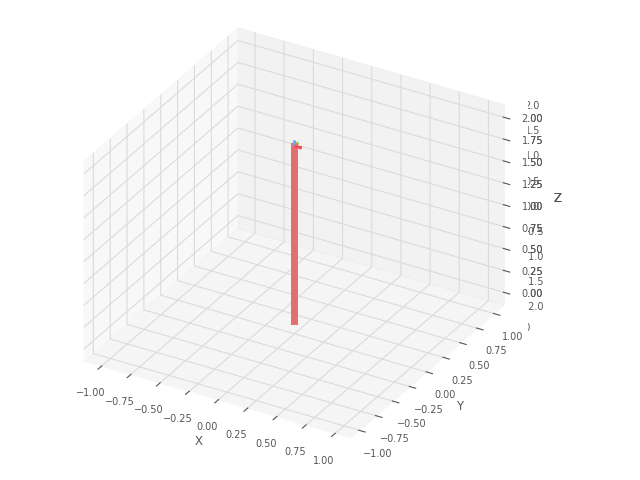

PyPlot3D backend, t = 0.05, scene:
  robot: Text(0.0, 0.0, '')

In [70]:
q = np.ndarray((1,0))
frame_chain.plot(q)

### 18. Configure and attach consecutive links 
Proceed in the same way to generate, configure and attach consecutive Links _L2,L3,L4_ with names _'b2','b3','b4'_ and corresponding joints with fixed transforms _tformrotz_, _tformtx_ and _tformrotx_. Connect them as a list so that link $b_{i-1}$ becomes the parent of link $b_i$, giving you a simple teaching frame chain for the myCobot 280 labs.

In [71]:
joint2 = ET.SE3(tformrotz)
L2 = Link(joint2, name='b2', parent=L1)

joint3 = ET.SE3(tformtx)
L3 = Link(joint3, name='b3', parent=L2)

joint4 = ET.SE3(tformrotx)
L4 = Link(joint4, name='b4', parent=L3)

link_chain = [L1, L2, L3, L4]
frame_chain = rtb.Robot(link_chain)

### 19. Display and visualize
Display and visualize the overall kinematic structure of your simplified frame chain. It should reflect the same transform order as the previous section.

ERobot: , 0 joints ()
┌──────┬──────┬───────┬────────┬─────────────────────┐
│ link │ link │ joint │ parent │ ETS: parent to link │
├──────┼──────┼───────┼────────┼─────────────────────┤
│    0 │ b1   │       │ BASE   │ SE3(0, 0, 2)        │
│    1 │ b2   │       │ b1     │ SE3(0°, -0°, 45°)   │
│    2 │ b3   │       │ b2     │ SE3(1, 0, 0)        │
│    3 │ @b4  │       │ b3     │ SE3(90°, -0°, 0°)   │
└──────┴──────┴───────┴────────┴─────────────────────┘



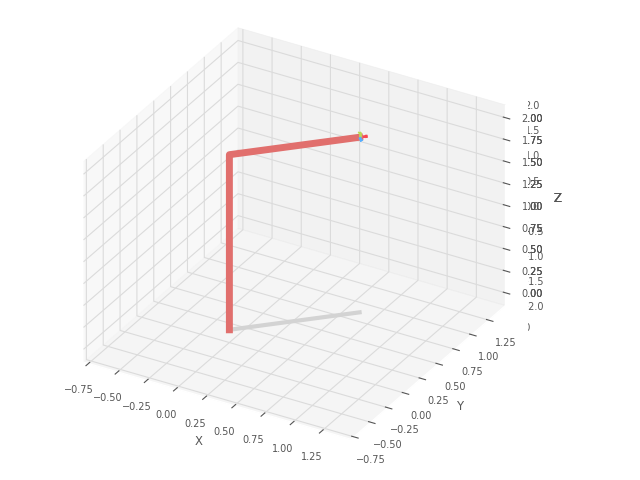

[(-2.0, 2.0), (-2.0, 2.0), (-2.0, 2.0)]

In [72]:
print(frame_chain)
q = np.ndarray((1,0))
frame_chain_fig =frame_chain.plot(q)
frame_chain_fig.ax.set(xlim=(-2, 2), ylim=(-2, 2),zlim=(-2,2))

### 20. Retrieve the transformation between two link frames 
Use `frame_chain.fkine(q, start=start_link, end=end_link)` to retrieve the transformation between two link frames. In this task, retrieve the transform from the base frame _'base'_ to the end frame _'b4'_ of the simplified chain. Here, _'b4'_ is only the end frame of this teaching chain, not the actual myCobot flange or TCP frame used in later labs. Use `frame_chain.base_link` for the start link and `frame_chain.ee_links[0]` for the end link.

In [73]:
q = np.ndarray((1,0))
# frame_chain.fkine(q) returns the transform from the base frame to the end frame of the simplified chain
start_link = frame_chain.base_link
end_link = frame_chain.ee_links[0]

tformdhchain = np.array(frame_chain.fkine(q, start=start_link, end=end_link))
print(tformdhchain)

[[ 7.0711e-01 -4.3298e-17  7.0711e-01  7.0711e-01]
 [ 7.0711e-01  4.3298e-17 -7.0711e-01  7.0711e-01]
 [ 0.0000e+00  1.0000e+00  6.1232e-17  2.0000e+00]
 [ 0.0000e+00  0.0000e+00  0.0000e+00  1.0000e+00]]


The transform should be an _SE3_ object. You can convert it to a _numpy array_ with `np.array(...)`.

### 21. Compare the manually defined transform with the simplified frame-chain transform
Check whether the transform _tformdhchain_ retrieved from the simplified frame chain is identical to the manually defined transform _tformdhc_ with respect to the current frame from task 8.

In [74]:
if (np.isclose(tformdhc, tformdhchain)).all():
    print('tformdhc and tformdhchain are equal')
else:
    print('tformdhc and tformdhchain are not equal')

tformdhc and tformdhchain are equal


### 22. Create a point cloud and visualize it
The code below generates a sample cuboid point cloud. This generated point cloud is sufficient for the exercise.

In [75]:
edgelength=0.2
c=np.arange(0,edgelength+edgelength/20,edgelength/20)
p=edgelength*np.ones((len(c)))
# Create sample point cloud data for a small cuboid at the origin.
p=np.concatenate((np.array((0*p, 0*p, c*0.6)),np.array((p, 0*p, c*0.6)),np.array((p, p*0.8, c*0.6)),np.array((0*p, p*0.8, c*0.6)),
            np.array((0*p, c*0.8, 0*p)),np.array((p, c*0.8, p*0.6)),np.array((0*p, c*0.8, p*0.6)),np.array((p, c*0.8, p*0)),
            np.array((c, 0*p, 0*p)),np.array((c, p*0.8, 0*p)),np.array((c, 0*p, p*0.6)),np.array((c, p*0.8, p*0.6))),axis=1)

If an optional `pointcloud.mat` file is provided alongside this notebook, you may load it with `scipy.io.loadmat(...)`. It is not required for this exercise, and the generated cuboid point cloud is the default.

In [76]:
notebook_path = os.getcwd()
pointcloud_path = os.path.join(notebook_path, 'pointcloud.mat')
if os.path.exists(pointcloud_path):
    data = scipy.io.loadmat(pointcloud_path)
    p = data['p']

Superimpose the point cloud on your simplified frame-chain visualization by plotting the points in the base frame.

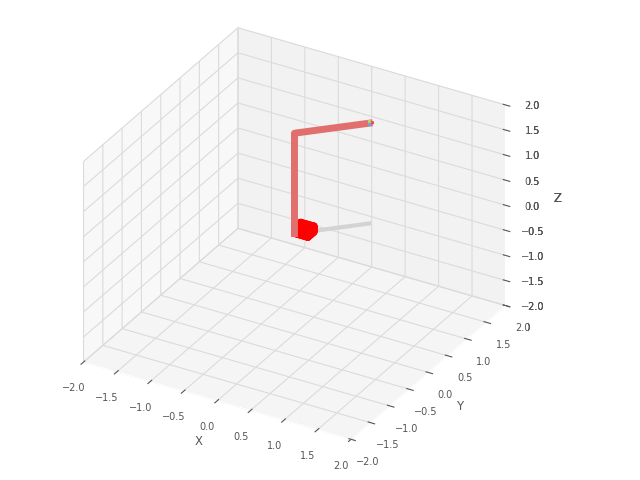

In [77]:
xlim = (-2,2)
ylim = (-2,2)
zlim = (-2,2)
pyplot = rtb.backends.PyPlot.PyPlot() # create a PyPlot backend
pyplot.launch()
ax = pyplot.ax                  
# Plot the point cloud in the base frame and overlay it with the chain.
ax.scatter(p[0,:], p[1,:], p[2,:], color='r')

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_zlim(zlim)

pyplot.add(frame_chain)   
pyplot.step()


### 23. Transform the point cloud into a frame
Transform the point cloud into frame _'b4'_. For that purpose, apply the homogeneous transform _tformdhchain_ to the point cloud _p_ by converting the 3-by-n point cloud into homogeneous 4-by-n form.

In [78]:
tp=tformdhchain @ np.vstack((p, np.ones((1, p.shape[1])))) # apply the transform to the homogeneous point-cloud data


Visualize the transformed point cloud. The blue cuboid should now be expressed with respect to the simplified end frame _'b4'_.

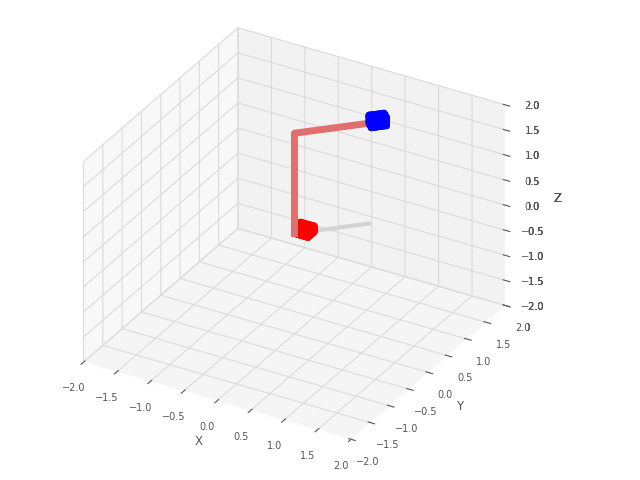

In [79]:
xlim = (-2,2)
ylim = (-2,2)
zlim = (-2,2)
pyplot = rtb.backends.PyPlot.PyPlot() # create a PyPlot backend
pyplot.launch()
ax = pyplot.ax                  
# Plot the point cloud in the base frame and overlay it with the chain.
ax.scatter(p[0,:], p[1,:], p[2,:], color='r')
ax.scatter(tp[0,:], tp[1,:], tp[2,:], color='b') # plot point cloud w.r.t. the simplified end frame b4

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_zlim(zlim)

pyplot.add(frame_chain)   
pyplot.step()

## Conversion to Euler Angles, Roll Pitch Yaw and Angle Axis
### 24. Euler angles, roll-pitch-yaw and angle-axis representation
Extract the Euler angles, roll-pitch-yaw and angle-axis representation of the rotation associated with _tformdhchain_ from task 20. These are the same orientation descriptions you will reuse later in the myCobot 280 labs.

Convention used in the myCobot 280 codebase: The RPY-to-rotation function builds $R = R_z(\text{yaw}) \cdot R_y(\text{pitch}) \cdot R_x(\text{roll})$, which is the ZYX intrinsic (equivalently XYZ extrinsic) convention. Keep this in mind when interpreting orientations in later labs.

In [80]:
eul= tr2eul(tformdhchain,flip=True)
print('Euler angles: '+str(eul))

rpy=tr2rpy(tformdhchain,'zyx')  # Note that the 'zyx' option does not work as expected and a manual reordering of the rpy would be required for further use
print('Roll-pitch-yaw: '+str(rpy))

axanga=tr2angvec(tformdhchain)
print('Angle-axis: '+str(axanga))

Euler angles: [ 2.3562 -1.5708 -1.5708]
Roll-pitch-yaw: [ 1.5708 -0.      0.7854]
Angle-axis: (1.7177715174584016, array([0.8629, 0.3574, 0.3574]))


## Animate Euler Angles and Roll Pitch Yaw Angles
Animate the sequence of rotations for 'ZYZ' Euler angles and 'XYZ' roll-pitch-yaw angles. Treat this as the same frame-rotation exercise you will use when reasoning about myCobot 280 tool orientation. Animate the rotating frame, the intermediate frames after each elemental rotation, and the arcs of rotation. Use the basic code for an elemental rotation about the z-axis as a starting point. Generate the rotation matrices with `R.from_euler(...)` and apply them to the original unit vectors `X0`, `Y0`, `Z0`. For RPY, use the reversed order (extrinsic composition), so the arguments change from $\phi,\vartheta,\psi$ to $\psi,\vartheta,\phi$. Rotate by $\phi=\frac{\pi}{3}, \vartheta=\frac{\pi}{3.5}, \psi=\frac{\pi}{4}$.


### 25. Animate Euler angles rotation by $\phi,\vartheta,\psi$

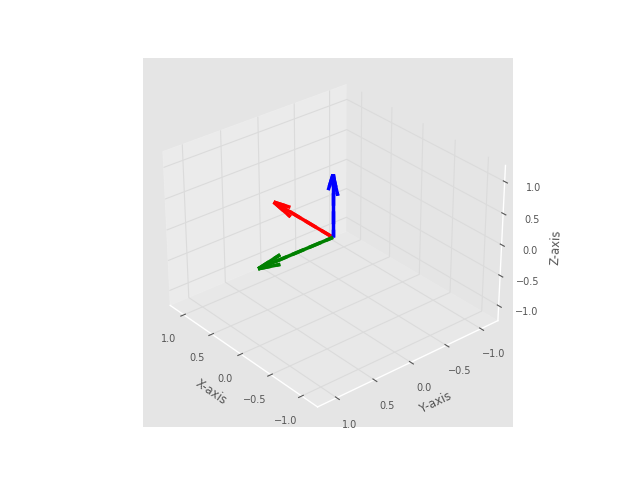

In [81]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
from scipy.spatial.transform import Rotation as R
import time

# Initialize the figure
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Set up the axes
ax.set_xlim([-1.25, 1.25])
ax.set_ylim([-1.25, 1.25])
ax.set_zlim([-1.25, 1.25])
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_zlabel('Z-axis')
ax.grid(True)
ax.view_init(elev=30, azim=140)

# Define the original frame (as column vectors)
O = np.array([0, 0, 0])  # Origin
X0 = np.array([1, 0, 0])  # X-axis vector
Y0 = np.array([0, 1, 0])  # Y-axis vector
Z0 = np.array([0, 0, 1])  # Z-axis vector

# Euler angles
phiF = np.pi / 3
thetaF = np.pi / 3.5
psiF = np.pi / 4
sequence = 'ZYZ'

# Initial plot of the original frame (solid)
quiver_X = ax.quiver(O[0], O[1], O[2], X0[0], X0[1], X0[2], color='r', linewidth=2.5)
quiver_Y = ax.quiver(O[0], O[1], O[2], Y0[0], Y0[1], Y0[2], color='g', linewidth=2.5)
quiver_Z = ax.quiver(O[0], O[1], O[2], Z0[0], Z0[1], Z0[2], color='b', linewidth=2.5)

# Dashed original frame for reference
ax.quiver(O[0], O[1], O[2], X0[0], X0[1], X0[2], color='r', linestyle='dashed', linewidth=2.5)
ax.quiver(O[0], O[1], O[2], Y0[0], Y0[1], Y0[2], color='g', linestyle='dashed', linewidth=2.5)
ax.quiver(O[0], O[1], O[2], Z0[0], Z0[1], Z0[2], color='b', linestyle='dashed', linewidth=2.5)

scale = 0.5
trace_X = ax.plot([scale * X0[0]], [scale * X0[1]], [scale * X0[2]], 'r', linewidth=2)[0]
trace_Y = ax.plot([scale * Y0[0]], [scale * Y0[1]], [scale * Y0[2]], 'g', linewidth=2)[0]
trace_Z = ax.plot([scale * Z0[0]], [scale * Z0[1]], [scale * Z0[2]], 'b', linewidth=2)[0]

# Update function for the animation
def update_phi(frame):
    phi = phiF * frame / 60  # First rotation along Z-axis (phi)
    theta = 0
    psi = 0
    
    # Compute rotation matrix
    rot_matrix = R.from_euler(sequence, [phi, theta, psi]).as_matrix()
    
    # Rotate the frame vectors
    X_rot = rot_matrix @ X0
    Y_rot = rot_matrix @ Y0
    Z_rot = rot_matrix @ Z0
    
    # Update the quiver data for the vectors
    quiver_X.set_segments([[[0, 0, 0], X_rot]])
    quiver_Y.set_segments([[[0, 0, 0], Y_rot]])
    quiver_Z.set_segments([[[0, 0, 0], Z_rot]])
    
    # Update the trace
    trace_X.set_data([scale * X_rot[0]], [scale * X_rot[1]])
    trace_X.set_3d_properties([scale * X_rot[2]])
    
    trace_Y.set_data([scale * Y_rot[0]], [scale * Y_rot[1]])
    trace_Y.set_3d_properties([scale * Y_rot[2]])
    
    trace_Z.set_data([scale * Z_rot[0]], [scale * Z_rot[1]])
    trace_Z.set_3d_properties([scale * Z_rot[2]])
    
    return quiver_X, quiver_Y, quiver_Z, trace_X, trace_Y, trace_Z

# Animation for theta
def update_theta(frame):
    phi = phiF
    theta = thetaF * frame / 60
    psi = 0

    # Compute rotation matrix
    rot_matrix = R.from_euler(sequence, [phi, theta, psi]).as_matrix()
    
    # Rotate the frame vectors
    X_rot = rot_matrix @ X0
    Y_rot = rot_matrix @ Y0
    Z_rot = rot_matrix @ Z0
    
    # Update the quiver data for the vectors
    quiver_X.set_segments([[[0, 0, 0], X_rot]])
    quiver_Y.set_segments([[[0, 0, 0], Y_rot]])
    quiver_Z.set_segments([[[0, 0, 0], Z_rot]])
    
    # Update the trace
    trace_X.set_data([scale * X_rot[0]], [scale * X_rot[1]])
    trace_X.set_3d_properties([scale * X_rot[2]])
    
    trace_Y.set_data([scale * Y_rot[0]], [scale * Y_rot[1]])
    trace_Y.set_3d_properties([scale * Y_rot[2]])
    
    trace_Z.set_data([scale * Z_rot[0]], [scale * Z_rot[1]])
    trace_Z.set_3d_properties([scale * Z_rot[2]])
    
    return quiver_X, quiver_Y, quiver_Z, trace_X, trace_Y, trace_Z

# Animation for psi
def update_psi(frame):
    phi = phiF
    theta = thetaF
    psi = psiF * frame / 60

    # Compute rotation matrix
    rot_matrix = R.from_euler(sequence, [phi, theta, psi]).as_matrix()
    
    # Rotate the frame vectors
    X_rot = rot_matrix @ X0
    Y_rot = rot_matrix @ Y0
    Z_rot = rot_matrix @ Z0
    
    # Update the quiver data for the vectors
    quiver_X.set_segments([[[0, 0, 0], X_rot]])
    quiver_Y.set_segments([[[0, 0, 0], Y_rot]])
    quiver_Z.set_segments([[[0, 0, 0], Z_rot]])
    
    # Update the trace
    trace_X.set_data([scale * X_rot[0]], [scale * X_rot[1]])
    trace_X.set_3d_properties([scale * X_rot[2]])
    
    trace_Y.set_data([scale * Y_rot[0]], [scale * Y_rot[1]])
    trace_Y.set_3d_properties([scale * Y_rot[2]])
    
    trace_Z.set_data([scale * Z_rot[0]], [scale * Z_rot[1]])
    trace_Z.set_3d_properties([scale * Z_rot[2]])
    
    return quiver_X, quiver_Y, quiver_Z, trace_X, trace_Y, trace_Z

# Animate first rotation (phi)
ani_phi = FuncAnimation(fig, update_phi, frames=60, interval=50, blit=False,repeat=False)

In [82]:
ani_theta = FuncAnimation(fig, update_theta, frames=60, interval=50, blit=False, repeat=False)
plt.draw()

In [83]:
ani_psi = FuncAnimation(fig, update_psi, frames=60, interval=50, blit=False, repeat=False)
plt.draw()

### 26. Animate RPY angles rotation by $\phi,\vartheta,\psi$

/home/corobot/venvs/mycobot/lib/python3.12/site-packages/matplotlib/animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


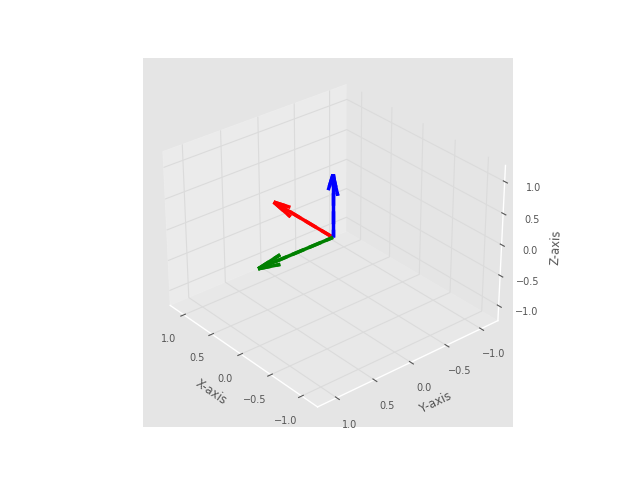

In [84]:
# Initialize the figure
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Set up the axes
ax.set_xlim([-1.25, 1.25])
ax.set_ylim([-1.25, 1.25])
ax.set_zlim([-1.25, 1.25])
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_zlabel('Z-axis')
ax.grid(True)
ax.view_init(elev=30, azim=140)

# Define the original frame (as column vectors)
O = np.array([0, 0, 0])  # Origin
X0 = np.array([1, 0, 0])  # X-axis vector
Y0 = np.array([0, 1, 0])  # Y-axis vector
Z0 = np.array([0, 0, 1])  # Z-axis vector

# RPY angles
phiF = np.pi / 3
thetaF = np.pi / 3.5
psiF = np.pi / 4
sequence = 'ZYX'

# Initial plot of the original frame (solid)
quiver_X = ax.quiver(O[0], O[1], O[2], X0[0], X0[1], X0[2], color='r', linewidth=2.5)
quiver_Y = ax.quiver(O[0], O[1], O[2], Y0[0], Y0[1], Y0[2], color='g', linewidth=2.5)
quiver_Z = ax.quiver(O[0], O[1], O[2], Z0[0], Z0[1], Z0[2], color='b', linewidth=2.5)

# Dashed original frame for reference
ax.quiver(O[0], O[1], O[2], X0[0], X0[1], X0[2], color='r', linestyle='dashed', linewidth=2.5)
ax.quiver(O[0], O[1], O[2], Y0[0], Y0[1], Y0[2], color='g', linestyle='dashed', linewidth=2.5)
ax.quiver(O[0], O[1], O[2], Z0[0], Z0[1], Z0[2], color='b', linestyle='dashed', linewidth=2.5)

scale = 0.5
trace_X = ax.plot([scale * X0[0]], [scale * X0[1]], [scale * X0[2]], 'r', linewidth=2)[0]
trace_Y = ax.plot([scale * Y0[0]], [scale * Y0[1]], [scale * Y0[2]], 'g', linewidth=2)[0]
trace_Z = ax.plot([scale * Z0[0]], [scale * Z0[1]], [scale * Z0[2]], 'b', linewidth=2)[0]

# Update function for the animation
def update_phi(frame):
    phi = phiF * frame / 60  # First rotation along Z-axis (phi)
    theta = 0
    psi = 0
    
    # Compute rotation matrix
    rot_matrix = R.from_euler(sequence, [psi, theta, phi]).as_matrix()
    
    # Rotate the frame vectors
    X_rot = rot_matrix @ X0
    Y_rot = rot_matrix @ Y0
    Z_rot = rot_matrix @ Z0
    
    # Update the quiver data for the vectors
    quiver_X.set_segments([[[0, 0, 0], X_rot]])
    quiver_Y.set_segments([[[0, 0, 0], Y_rot]])
    quiver_Z.set_segments([[[0, 0, 0], Z_rot]])
    
    # Update the trace
    trace_X.set_data([scale * X_rot[0]], [scale * X_rot[1]])
    trace_X.set_3d_properties([scale * X_rot[2]])
    
    trace_Y.set_data([scale * Y_rot[0]], [scale * Y_rot[1]])
    trace_Y.set_3d_properties([scale * Y_rot[2]])
    
    trace_Z.set_data([scale * Z_rot[0]], [scale * Z_rot[1]])
    trace_Z.set_3d_properties([scale * Z_rot[2]])
    
    return quiver_X, quiver_Y, quiver_Z, trace_X, trace_Y, trace_Z

# Animation for theta
def update_theta(frame):
    phi = phiF
    theta = thetaF * frame / 60
    psi = 0

    # Compute rotation matrix
    rot_matrix = R.from_euler(sequence, [psi, theta, phi]).as_matrix()
    
    # Rotate the frame vectors
    X_rot = rot_matrix @ X0
    Y_rot = rot_matrix @ Y0
    Z_rot = rot_matrix @ Z0
    
    # Update the quiver data for the vectors
    quiver_X.set_segments([[[0, 0, 0], X_rot]])
    quiver_Y.set_segments([[[0, 0, 0], Y_rot]])
    quiver_Z.set_segments([[[0, 0, 0], Z_rot]])
    
    # Update the trace
    trace_X.set_data([scale * X_rot[0]], [scale * X_rot[1]])
    trace_X.set_3d_properties([scale * X_rot[2]])
    
    trace_Y.set_data([scale * Y_rot[0]], [scale * Y_rot[1]])
    trace_Y.set_3d_properties([scale * Y_rot[2]])
    
    trace_Z.set_data([scale * Z_rot[0]], [scale * Z_rot[1]])
    trace_Z.set_3d_properties([scale * Z_rot[2]])
    
    return quiver_X, quiver_Y, quiver_Z, trace_X, trace_Y, trace_Z

# Animation for psi
def update_psi(frame):
    phi = phiF
    theta = thetaF
    psi = psiF * frame / 60

    # Compute rotation matrix
    rot_matrix = R.from_euler(sequence, [psi, theta, phi]).as_matrix()
    
    # Rotate the frame vectors
    X_rot = rot_matrix @ X0
    Y_rot = rot_matrix @ Y0
    Z_rot = rot_matrix @ Z0
    
    # Update the quiver data for the vectors
    quiver_X.set_segments([[[0, 0, 0], X_rot]])
    quiver_Y.set_segments([[[0, 0, 0], Y_rot]])
    quiver_Z.set_segments([[[0, 0, 0], Z_rot]])
    
    # Update the trace
    trace_X.set_data([scale * X_rot[0]], [scale * X_rot[1]])
    trace_X.set_3d_properties([scale * X_rot[2]])
    
    trace_Y.set_data([scale * Y_rot[0]], [scale * Y_rot[1]])
    trace_Y.set_3d_properties([scale * Y_rot[2]])
    
    trace_Z.set_data([scale * Z_rot[0]], [scale * Z_rot[1]])
    trace_Z.set_3d_properties([scale * Z_rot[2]])
    
    return quiver_X, quiver_Y, quiver_Z, trace_X, trace_Y, trace_Z

# Animate first rotation (phi)
ani_phi = FuncAnimation(fig, update_phi, frames=60, interval=50, blit=False,repeat=False)

In [85]:
ani_psi = FuncAnimation(fig, update_psi, frames=60, interval=50, blit=False, repeat=False)
plt.draw()

In [86]:
ani_theta = FuncAnimation(fig, update_theta, frames=60, interval=50, blit=False, repeat=False)
plt.draw()

## Representation Singularities
These singularities matter later when describing myCobot 280 tool orientation with roll-pitch-yaw angles.

The task starts with the roll, pitch and yaw angles 

$\alpha = \pi/4, \beta = \pi/2, \gamma = \pi/4$.
### 27. Compose a rotation matrix
From the roll, pitch and yaw angles $\alpha,\beta,\gamma$, compose a rotation matrix _rotmrpy_ __R__ with `rpy2tr(...)` and extract the 3-by-3 rotation block. 

In [87]:
rotmrpy = rpy2tr(np.pi/4, np.pi/2, np.pi/4, order='zyx')[:3, :3]  # e.g. extract the rotation block from rpy2tr(...)
print(rotmrpy)

[[ 4.3298e-17 -1.0147e-17  1.0000e+00]
 [ 4.3298e-17  1.0000e+00 -1.0147e-17]
 [-1.0000e+00  4.3298e-17  4.3298e-17]]


### 28. Transform rotation matrix back into roll, pitch and yaw angles
Transform the rotation matrix __R__ back into roll, pitch and yaw angles. Compare the result with the original angles $\alpha = \pi/4, \beta = \pi/2$ and $\gamma = \pi/4$. Note any ambiguity that appears at this singular configuration. 

In [88]:
alphabetagamma = tr2rpy(rotmrpy, order='zyx')
print(alphabetagamma)

[0.0000e+00 1.5708e+00 1.0147e-17]


## Quaternion Slerps
Euler angle interpolation (not part of the main exercise sequence, included for comparison)

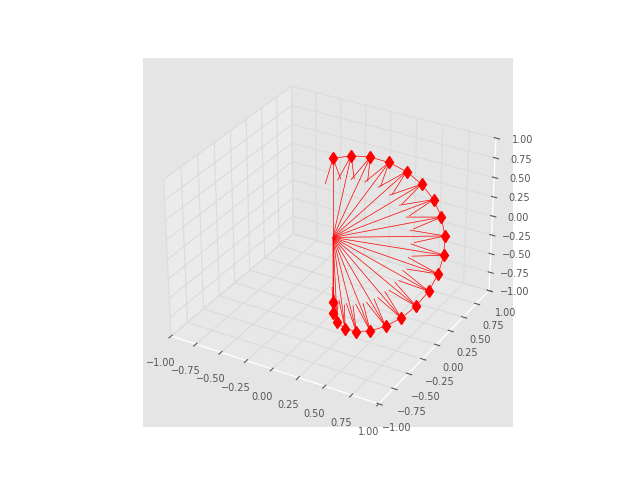

In [89]:
path = np.arange(0,1.05,0.05)
p = np.array([1,0,0])

euler_angles = np.array([[np.pi/3, -np.pi/2, 0]]) + \
               np.vstack((-path*2*np.pi/3, path*np.pi*1.05, path*0)).T
interpolated_euler = R.from_euler('ZYX', euler_angles).as_matrix()

rPeul = np.zeros((21, 3))
for i in range(21):
    rPeul[i, :] = np.dot(interpolated_euler[i, :, :], p)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot3D(rPeul[:, 0], rPeul[:, 1], rPeul[:, 2], 'r-d')
ax.quiver(np.zeros(21), np.zeros(21), np.zeros(21),
          rPeul[:, 0], rPeul[:, 1], rPeul[:, 2], color='r')
ax.set_xlim(-1,1)
ax.set_ylim(-1,1)
ax.set_zlim(-1,1)
plt.show()

### 29. RPY angles (ZYX Euler) to quaternion
Calculate the quaternion _q0_ and _q1_ that correspond to the initial $[\psi,\vartheta,\varphi]_i = [\pi/3, -\pi/2, 0]$ and final ZYX Euler angles $[\psi,\vartheta,\varphi]_f = [-\pi/3, \pi/2+\pi/20, 0]$ with `R.from_euler(...)`.

In [90]:
q0 = R.from_euler('ZYX', [np.pi/3, -np.pi/2, 0], degrees=False)
q1 = R.from_euler('ZYX', [-np.pi/3, np.pi/2 + np.pi/20, 0], degrees=False)

### 30. SLERP interpolation
Calculate the quaternion array _interp_rots_ from the quaternion slerp between the initial quaternion _q0_ and the final quaternion _q1_ with increments of 0.05.

It is recommended to use _scipy.spatial.transform.Slerp_ class for this section.

In [91]:
key_rots = R.concatenate([q0, q1])
key_times = [0, 1]
slerp = Slerp(key_times, key_rots)
times = np.arange(0, 1.05, 0.05)
interp_rots = slerp(times)

### 31. Apply the array of interpolated quaternions to a vector
Apply the array of interpolated quaternions to the vector p=[1,0,0] with

In [92]:
p = [1,0,0]
rP = interp_rots.apply(p)

### 32. Visualize rotations of the vector by the quaternion slerp
Visualize rotations of the vector p=[1, 0, 0] by the quaternion slerp and compare the trajectory with the Euler-angle interpolation plotted above.

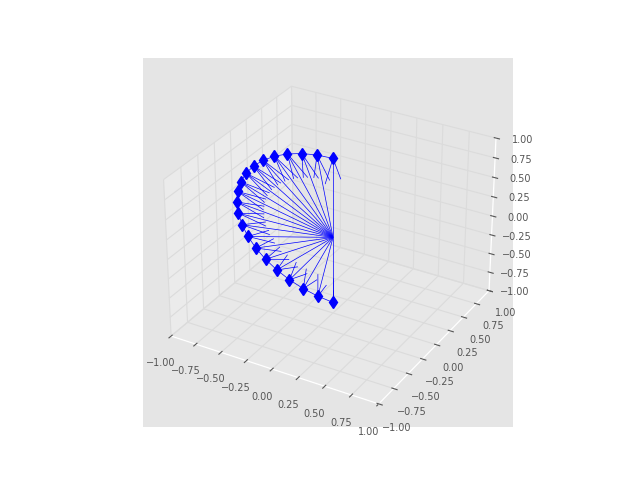

In [93]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot3D(rP[:, 0], rP[:, 1], rP[:, 2], 'b-d')
ax.quiver(np.zeros(21), np.zeros(21), np.zeros(21),
          rP[:, 0], rP[:, 1], rP[:, 2], color='b')
ax.set_xlim(-1,1)
ax.set_ylim(-1,1)
ax.set_zlim(-1,1)
plt.show()

### 33. Remove the offset to obtain the opposite great-circle arc
Modify the final rotation to $[\psi,\vartheta,\varphi]_f = [-\pi/3, \pi/2, 0]$. What is the effect on the great circle arc obtained by SLERP?

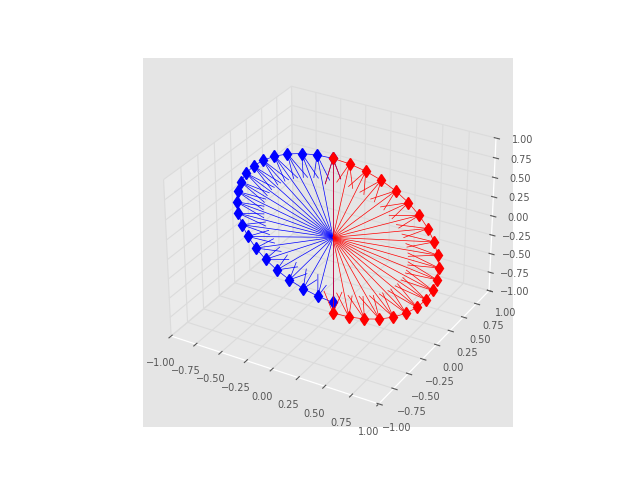

In [94]:
q2 = R.from_euler('ZYX', [-np.pi/3, np.pi/2, 0])
key_rots = R.concatenate([q0, q2])
key_times = [0, 1]
slerp = Slerp(key_times, key_rots)
times = np.arange(0, 1.05, 0.05)
interp_rots = slerp(times)

p = [1,0,0]
rP = interp_rots.apply(p)

ax.plot3D(rP[:, 0], rP[:, 1], rP[:, 2], 'r-d')
ax.quiver(np.zeros(21), np.zeros(21), np.zeros(21),
          rP[:, 0], rP[:, 1], rP[:, 2], color='r')
ax.set_xlim(-1,1)
ax.set_ylim(-1,1)
ax.set_zlim(-1,1)


plt.show()